<a href="https://colab.research.google.com/github/cit-24-01-0024/NLP_Group_24-/blob/feature%2Fsachila-model/SENTISCOPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q scikit-learn pandas numpy nltk textblob tensorflow matplotlib seaborn imbalanced-learn wordcloud
import pandas as pd, numpy as np, re, nltk
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!git clone -b feature/sachila-model https://github.com/cit-24-01-0024/NLP_Group_24-.git

Cloning into 'NLP_Group_24-'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 28 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 2.79 MiB | 13.58 MiB/s, done.


In [6]:
%cd NLP_Group_24-

[Errno 2] No such file or directory: 'NLP_Group_24-'
/content/NLP_Group_24-


In [7]:
!ls

data  README.md  requirements.txt


In [8]:
!pwd
!ls -l


/content/NLP_Group_24-
total 12
drwxr-xr-x 3 root root 4096 Jul 29 09:35 data
-rw-r--r-- 1 root root  125 Jul 29 09:35 README.md
-rw-r--r-- 1 root root  113 Jul 29 09:35 requirements.txt


In [9]:
%cd /content/NLP_Group_24-

/content/NLP_Group_24-


In [10]:
!find . -name "*.csv"

./data/raw/amazon.csv


In [12]:
import pandas as pd

df = pd.read_csv("data/raw/amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [13]:
df = pd.read_csv('data/raw/amazon.csv')
df.info()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [15]:
def rating_to_sentiment(r):
    if r <= 2: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

# Convert the 'rating' column to a numeric type, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
print(df['sentiment'].value_counts())

sentiment
Positive    1460
Neutral        4
Negative       1
Name: count, dtype: int64


In [16]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
Positive,0.996587
Neutral,0.002730
Negative,0.000683


In [31]:
from sklearn.model_selection import train_test_split
import os

# Filter out rows where the sentiment class has only one member
sentiment_counts = df['sentiment'].value_counts()
single_occurrence_sentiments = sentiment_counts[sentiment_counts == 1].index
df_filtered = df[~df['sentiment'].isin(single_occurrence_sentiments)]

# Ensure df_filtered now includes the 'final_text' column from the processed df
# (The 'final_text' column would have been added to the main df by previous cells)

train_df, test_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered['sentiment'], random_state=42)

# Create the 'data/processed' directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

train_df.to_csv('data/processed/train.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

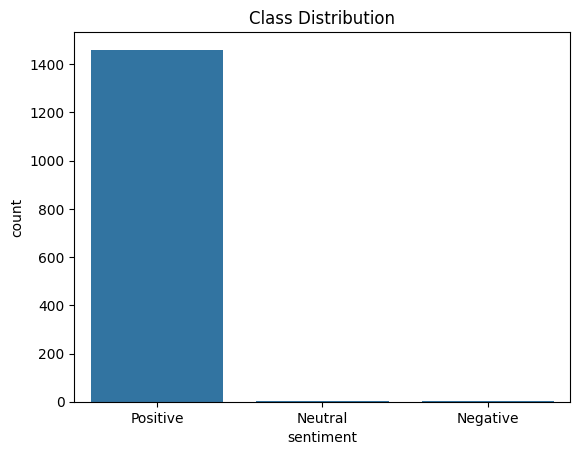

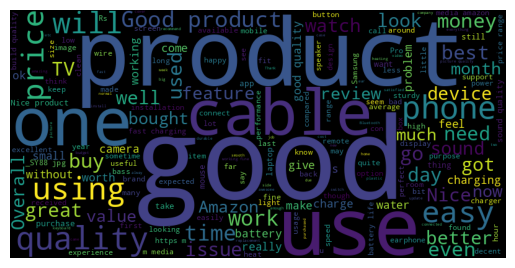

In [22]:
sns.countplot(x='sentiment', data=df)
plt.title('Class Distribution')
plt.show()

from wordcloud import WordCloud
positive_text = ' '.join(df[df.sentiment=='Positive']['review_content'].astype(str))
wc = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wc); plt.axis('off'); plt.show()

In [23]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review_content'].apply(clean_text)

In [26]:
import nltk
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

In [27]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [28]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])
df['final_text'] = df['tokens'].apply(lambda x: ' '.join(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [33]:
from imblearn.over_sampling import RandomOverSampler

# Define X_train and y_train from the previously created train_df
# X_train should be a 2-dimensional container (e.g., DataFrame) for fit_resample
X_train = train_df[['final_text']]
y_train = train_df['sentiment']

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)